# 02 — DiscoverLLM multi-turn preferences EDA (official dataset)

**Questions this notebook answers**

1. What is the structure / fields of each record in the official DiscoverLLM dataset?
2. How big is the corpus per domain? What do the preference `score`s, candidates-per-turn, and turns-per-conversation look like?
3. What is the intent-criteria **hierarchy** size distribution (nodes per tree, depth), and what do a few example trees look like?

Read-only; loads the official dataset from the HuggingFace Hub. (This replaces the earlier
reproduction-based notebook — the analysis now uses the published DiscoverLLM data.)

## Data source

Official dataset: **`kixlab/DiscoverLLM-multiturn-preferences`** (HuggingFace), from the
*DiscoverLLM (ICML 2026)* collection — paper **arXiv:2602.03429**.

Three **domain configs**: `creative_writing`, `svg_drawing`, `technical_writing` (each split `train`).
Each row is **one assistant candidate at one turn**, with fields:
`artifact_id`, `turn_id`, `assistant_index`, `prompt` (chat messages), `completion`, `score`
(preference score), `criteria_history`, `conv_id`, `source_dataset`/`source_id`/`source_metadata`.

The DiscoverLLM **intent representation** is embedded in `criteria_history` (a JSON string):
a list of criteria, each `{criterion, abstractions, hierarchy}`, where `hierarchy` is a tree of
`{id, text, children}` nodes with dot-notation ids — the same shape DiscoverLLM's
hierarchy-organization stage produces. The same hierarchies repeat across a record's
turns/candidates, so for the tree distribution we **dedupe to one per artifact**.

In [1]:
import os
import json
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load all three domain configs and concatenate (with a `domain` column).
DATASET = "kixlab/DiscoverLLM-multiturn-preferences"
CONFIGS = ["creative_writing", "svg_drawing", "technical_writing"]

frames = []
for cfg in CONFIGS:
    ds = load_dataset(DATASET, cfg, split="train", token=os.environ.get("HF_TOKEN"))
    df = ds.to_pandas()
    df["domain"] = cfg
    frames.append(df)
    print(f"{cfg:18} {len(df):5d} rows")

data = pd.concat(frames, ignore_index=True)
print(f"\ntotal rows: {len(data):,}")
print("columns:", list(data.columns))

creative_writing    3052 rows
svg_drawing         3264 rows
technical_writing   3002 rows

total rows: 9,318
columns: ['artifact_id', 'turn_id', 'assistant_index', 'prompt', 'completion', 'score', 'criteria_history', 'conv_id', 'source_dataset', 'source_id', 'source_metadata', 'domain']


In [3]:
# (a) Structure / fields of one record (values truncated).
rec = data.iloc[0]
for col in data.columns:
    print(f"{col:16}: {str(rec[col])[:150]}")

artifact_id     : artifact_1
turn_id         : 1
assistant_index : 0
prompt          : [{'content': 'can you write a short story about how a band got its name, told from someone in the band', 'role': 'user'}]
completion      : **Title: The Name We Wore**

The dim lights of the cramped rehearsal room flickered as I leaned against the wall, a guitar strap slung over my shoulde
score           : 0.513
criteria_history: [[{"criterion": "First-person narrative from a band member's perspective using conversational, casual tone that directly addresses the reader. Establi
conv_id         : 1
source_dataset  : euclaise/WritingPrompts_preferences
source_id       : p532c2
source_metadata : {"post_row": 532, "comment_index": 2, "post_title": "[WP] You are the aging lead singer of one of the most prolific music groups of all time. Finally,
domain          : creative_writing


rows per domain:
 domain
svg_drawing          3264
creative_writing     3052
technical_writing    3002
Name: count, dtype: int64 

candidates per (conv, turn):
count    4659.0
mean        2.0
std         0.0
min         2.0
25%         2.0
50%         2.0
75%         2.0
max         2.0
dtype: float64 

turns per conversation:
count    1484.000000
mean        3.139488
std         1.008436
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: turn_id, dtype: float64


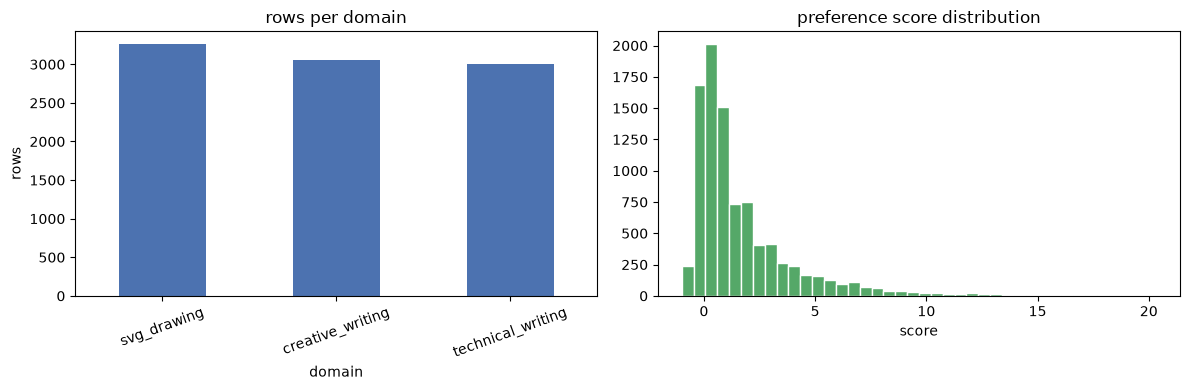

In [4]:
# (b) Corpus shape: rows per domain, preference scores, candidates per turn, turns per conv.
rows_per_domain = data["domain"].value_counts()
print("rows per domain:\n", rows_per_domain, "\n")

candidates_per_turn = data.groupby(["domain", "conv_id", "turn_id"]).size()
print("candidates per (conv, turn):"); print(candidates_per_turn.describe(), "\n")

turns_per_conv = data.groupby(["domain", "conv_id"])["turn_id"].nunique()
print("turns per conversation:"); print(turns_per_conv.describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
rows_per_domain.plot.bar(ax=axes[0], color="#4C72B0")
axes[0].set_title("rows per domain"); axes[0].set_ylabel("rows")
axes[0].tick_params(axis="x", rotation=20)
axes[1].hist(data["score"].dropna().values, bins=40, color="#55A868", edgecolor="white")
axes[1].set_title("preference score distribution"); axes[1].set_xlabel("score")
plt.tight_layout(); plt.show()

In [5]:
# (c) Parse the intent-criteria hierarchies out of criteria_history.

def iter_nodes(node):
    yield node
    for child in node.get("children", []):
        yield from iter_nodes(child)

def tree_depth(node):
    children = node.get("children", [])
    return 1 if not children else 1 + max(tree_depth(c) for c in children)

def extract_hierarchies(criteria_history):
    """Return every `hierarchy` root tree in a criteria_history JSON string,
    de-duplicated by criterion text (the same criterion recurs across turns)."""
    roots = []
    try:
        parsed = json.loads(criteria_history) if isinstance(criteria_history, str) else criteria_history
    except Exception:
        return roots
    stack, seen = [parsed], set()
    while stack:
        x = stack.pop()
        if isinstance(x, list):
            stack.extend(x)
        elif isinstance(x, dict):
            if isinstance(x.get("hierarchy"), list):
                key = str(x.get("criterion", ""))[:80]
                if key not in seen:
                    seen.add(key)
                    roots.extend(x["hierarchy"])
            for v in x.values():
                if isinstance(v, (list, dict)):
                    stack.append(v)
    return roots

# One representative criteria_history per (domain, artifact) = the longest one seen.
rep = (data.assign(_clen=data["criteria_history"].fillna("").str.len())
            .sort_values("_clen", ascending=False)
            .drop_duplicates(["domain", "artifact_id"]))

tree_rows = []
for _, r in rep.iterrows():
    for root in extract_hierarchies(r["criteria_history"]):
        tree_rows.append({"domain": r["domain"], "artifact_id": r["artifact_id"],
                          "n_nodes": sum(1 for _ in iter_nodes(root)), "depth": tree_depth(root)})

trees = pd.DataFrame(tree_rows)
print(f"unique artifacts: {len(rep)} | intent trees extracted: {len(trees)}")
if not trees.empty:
    print(trees[["n_nodes", "depth"]].describe())

unique artifacts: 1484 | intent trees extracted: 8141
           n_nodes        depth
count  8141.000000  8141.000000
mean      4.866847     2.959956
std       5.321318     1.496061
min       1.000000     1.000000
25%       2.000000     2.000000
50%       3.000000     3.000000
75%       6.000000     4.000000
max      42.000000     9.000000


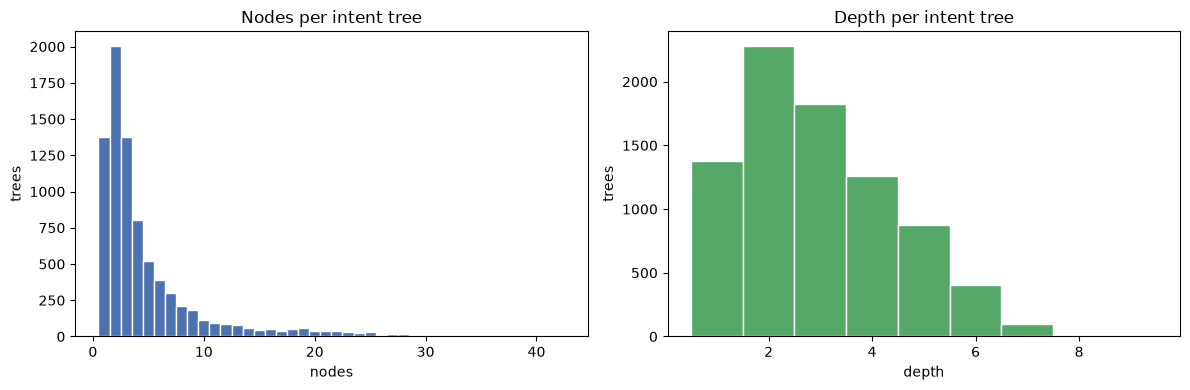

In [6]:
# (c cont.) Intent-tree size and depth distributions.
if not trees.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(trees["n_nodes"], bins=range(1, int(trees["n_nodes"].max()) + 2),
                 align="left", color="#4C72B0", edgecolor="white")
    axes[0].set_title("Nodes per intent tree"); axes[0].set_xlabel("nodes"); axes[0].set_ylabel("trees")
    axes[1].hist(trees["depth"], bins=range(1, int(trees["depth"].max()) + 2),
                 align="left", color="#55A868", edgecolor="white")
    axes[1].set_title("Depth per intent tree"); axes[1].set_xlabel("depth"); axes[1].set_ylabel("trees")
    plt.tight_layout(); plt.show()

In [7]:
# (c cont.) Render a couple of example intent trees as indented text.

def render_tree(node, indent=0):
    pad = "    " * indent
    lines = [f"{pad}[{node.get('id')}] {node.get('text')}"]
    for child in node.get("children", []):
        lines.extend(render_tree(child, indent + 1))
    return lines

shown = 0
for _, r in rep.iterrows():
    roots = extract_hierarchies(r["criteria_history"])
    if not roots:
        continue
    print("=" * 70)
    print(f"domain={r['domain']}  artifact={r['artifact_id']}")
    for root in roots[:2]:
        print("\n".join(render_tree(root)))
        print("-" * 40)
    shown += 1
    if shown >= 2:
        break

domain=creative_writing  artifact=artifact_273
[1] First-person narrative monologue
----------------------------------------
[2] Narrator is a local resident directly addressing a newcomer
----------------------------------------
domain=creative_writing  artifact=artifact_342
[1] First-person narrative voice
----------------------------------------
[2] Addresses another character
    [2.1] Direct address to daughter
        [2.1.1] Structured as a letter from parent to daughter
            [2.1.1.1] Letter intended for delivery on a future date
                [2.1.1.1.1] Letter intended for delivery on daughter's future milestone birthday
                    [2.1.1.1.1.1] Letter intended for delivery on daughter's sixteenth birthday
----------------------------------------


## Relation to the real-conversation trees (the comparison baseline)

This artifact-derived distribution is the **baseline** for the thesis comparison. DiscoverLLM builds
intent trees from **synthetic artifacts** (the trees analyzed here); the thesis idea is to build
DiscoverLLM-style intent trees from **real conversations** (ThoughtTrace, via the NB3 extraction) and
compare the two.

- **DiscoverLLM (official, here):** per-`(artifact, turn, candidate)` **preference** rows; the latent
  intent is a hierarchy of **criteria** (`abstract → specific`, `{id, text, children}`) *synthesized*
  over an artifact.
- **Real conversations (NB1 / NB3):** DiscoverLLM-style trees *extracted* from actual ThoughtTrace
  dialogues, grounded in reaction evidence.

The structural comparison (nodes, depth, branching) of these two tree sources is in **NB4**.